<img src="images/purple_net.jpeg" alt="purple_net"> 

# **<font color="purple">Train, Test, Evaluate -- Lab 1</font>**
### **<font color="purple">Prof. Tiziana Ligorio</font>**
### **<font color="purple">Hunter College of The City University of New York</font>**

---
---


# Make a copy of this notebook in your drive so you can edit it

This notebook is based on (but also diverges from) Ch2 of our Textbook: [Hands-on Machine Learning with Scikit-Lern, Keras & TensorFlow](https://www.oreilly.com/library/view/hands-on-machine-learning/9781098125967/?_gl=1*1g71y4*_ga*ODk5NDAxODkyLjE3MDUwODM4Mjg.*_ga_092EL089CH*MTcwNTA4MzgyOC4xLjEuMTcwNTA4Mzg3MC4xOC4wLjA.).
The focus here is not yet on the deep learning model we will use. (For now we will use a linear regression, which tries to fit numeric data to a straight line.) Today we will focus on the ***Data Preparation*** and the  ***Supervised Learning*** process:
1. [Load and visualize/explore the data](#exploration)
1. [Partition the data into Training and Test set](#partition)
2. [Data Preprocessing](#preprocessing)
3. [Select and Train the Model](#model)
4. [Evaluate the Model](#evaluate)

In future labs, we will train different types of Neural Networks within the supervised learnign framework. The five steps listed above will always stay the same, for every model we train.

In [1]:
# import the packages we will use
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import sklearn  # python ML package
import tarfile # used to decompress the data file


In this lab we work with the
[California Housing Prices Dataset:](https://www.kaggle.com/camnugent/california-housing-prices)
Median house prices for California districts derived from the 1990 census.

**We will use this data to predict the median house price from the 9 features provided.**

In [2]:
# load the data
!wget https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.tgz
!ls #list the files

--2026-03-16 22:30:39--  https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.tgz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 409488 (400K) [application/octet-stream]
Saving to: ‘housing.tgz’

housing.tgz         100%[===================>] 399,89K  --.-KB/s    in 0,07s   

2026-03-16 22:30:39 (5,65 MB/s) - ‘housing.tgz’ saved [409488/409488]

Lab2_Train_Test_Evaluate.ipynb
Lab3_torch.ipynb
Lab4_ANN-Classification_MatrixMultiplication_torch.ipynb
Lab5_ANN-Images_torch.ipynb
Lab6-DNN-Regression_torch.ipynb
README.md
housing.tgz
images


In [3]:
# extract the .tgz file
tar = tarfile.open("housing.tgz")
tar.extractall()
tar.close()

/var/folders/64/wb5ckbx51jzbktv33n1gdxhw0000gn/T/ipykernel_71935/1136875216.py:3: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


In [4]:
!ls


Lab2_Train_Test_Evaluate.ipynb
Lab3_torch.ipynb
Lab4_ANN-Classification_MatrixMultiplication_torch.ipynb
Lab5_ANN-Images_torch.ipynb
Lab6-DNN-Regression_torch.ipynb
README.md
housing.csv
housing.tgz
images


In [5]:
# now load the csv file into a pdandas dataframe
housing_data = pd.read_csv('housing.csv')


<a id="exploration"></a>
# Explore the Data
---

In [6]:
# take a look at the first few rows
housing_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Notice we have 10 columns, 9 features from which we will try to predict the label `median_house_value`.

Look at the numbers, do they make sense?

### Something is iffy! Let's keep exploring

In [7]:
# find out how many instances in the dataset (remember we refer to this as m)
# and how many feature (we refer to this as n)
housing_data.shape

(20640, 10)

From inpsecting the first few rows, we observe that we have both numeric and categorical data.

We have one categorical column: `ocean_proximity`

In [8]:
# display the possible values for that categorical feature and number of instances for each value
housing_data["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

We can observe the same data with a plot.

<Axes: xlabel='ocean_proximity', ylabel='Count'>

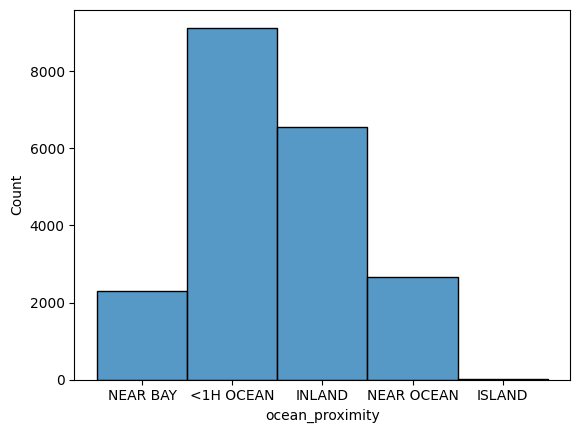

In [9]:
# plot a seaborn histplot of the categorical column
sns.histplot(housing_data['ocean_proximity'])

You can see that the plot alone makes it difficult to understand what's going on with `ISLAND`, so it's nice to look at the numbers as well.

Now let's look at the numeric data:

In [10]:
# use the dataframe info() method to get type and count information for the numeric columns information
housing_data.info()


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


We see that `total_bedrooms` has missing values because there are fewer than `m` (20640) non-null values in that column. You can also directly count how many null values per column.

In [11]:
# use the dataframe isnull() method and sum the result to count the number of null values per column
housing_data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Why do we want to know about missing values? When are missing values a problem and what can we do about it?  
Discuss with your partner.

When you are done discussing, let's continue our exploration of the data. We will do some data preprocessing later.

In [12]:
# display the stats for the dataframe
housing_data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Note that the `describe()` reports statistics for the numeric data only, `ocean_proximity` does not appear here.  

The statistics reported above don't make much sense for latitude and longitude, so we can ignore those.

Let's visualize the meaningful numbers with a plot.

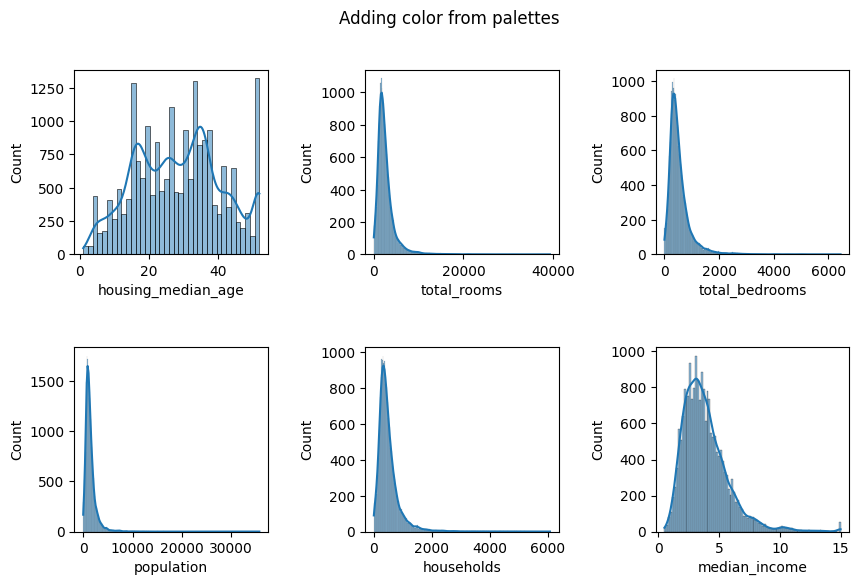

In [13]:
# observe the histogram for each numeric column (excluding latitude and longitude as well as the target median_house_value)

fig, axes = plt.subplots(2,3, figsize=(10,6))
fig.suptitle("Adding color from palettes")

sns.histplot(housing_data['housing_median_age'], ax=axes[0,0],kde=True);
sns.histplot(housing_data['total_rooms'], ax=axes[0,1],kde=True);
sns.histplot(housing_data['total_bedrooms'], ax=axes[0,2],kde=True);
sns.histplot(housing_data['population'], ax=axes[1,0],kde=True);
sns.histplot(housing_data['households'], ax=axes[1,1],kde=True);
sns.histplot(housing_data['median_income'], ax=axes[1,2],kde=True);
plt.subplots_adjust(wspace=0.5, hspace=0.5)

plt.show()

<img src="images/eyebrow.jpeg" alt="emoji" width="100"> 
   
By now you should be really bothered, a lot of these numbers don't look right, right???

This is typycal, you often need to go to the source to understand the data better, and often need to seek expert knowledge too. In our case the data comes from the California census of 1990, but contrary to what one would imagine, data here is reported per ***block*** not per household (each instance, each row, is a block not a single house), where "a block on average includes 1425.5 individuals living in a geographically compact area", you can think of these as **districts**. Ok so now 1425 individuals / 500 total_bedrooms makes more sense!  
Here are the column descriptions:  
* `longitude`:	A measure of how far west a house is; a higher value is farther west. Longitude values range from -180 to +180
* `latitude`	A measure of how far north a house is; a higher value is farther north. Latitude values range from -90 to +90
* `housing_median_age`:	Median age of a house within a block; a lower number is a newer building, capped at 50
* `total_rooms`:	Total number of rooms within a block
* `total_bedrooms`:	Total number of bedrooms within a block
* `population`:	Total number of people residing within a block
* `households`:	Total number of households, a group of people residing within a home unit, for a block
* `median_income`:	Median income for households within a block of houses (measured in tens of thousands of US Dollars)
* `median_house_value`	Median house value for households within a block (measured in US Dollars), capped at $500,000

*Note:* the column descriptions were taken as they are on the [California Housing Prices Dataset](https://www.kaggle.com/camnugent/california-housing-prices), although if all other columns refer to an entire block (district), the latitude and longitude too probably do not refer to a specific household but rather the rough location of the district.

Can we spot some correlations between features and our target?

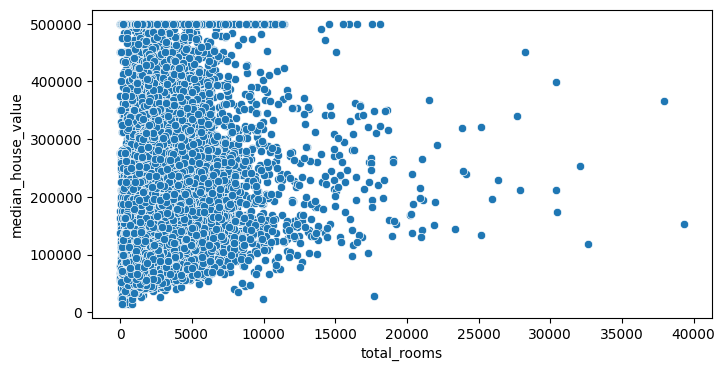

In [14]:
# plot a scatterplot of  median_house_value against total_rooms
# recall, if you want to modify the size of your figure, you can use plt.figure(figsize=(w,h)) before plotting with sns

plt.figure(figsize=(8,4))
sns.scatterplot(x='total_rooms', y='median_house_value', data=housing_data);


Not much here, let's look at another one:

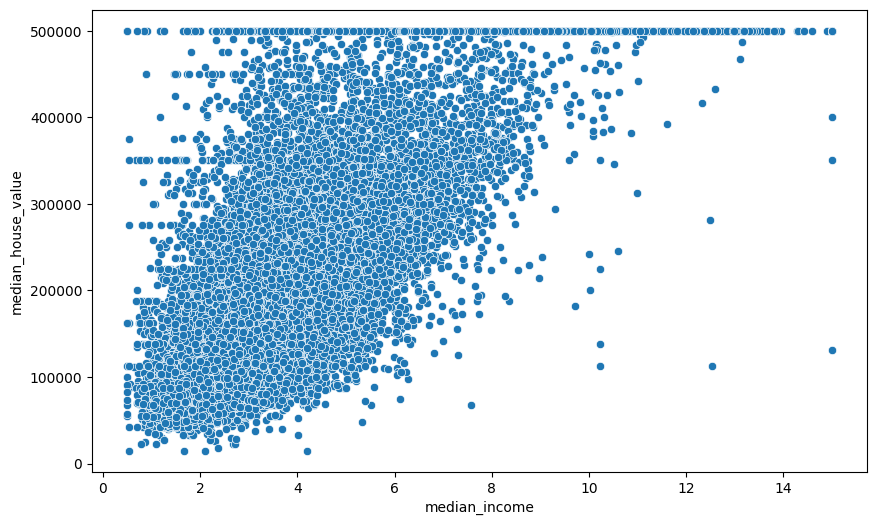

In [15]:
# plot a scatterplot of  median_house_value against median_income
# recall, if you want to modify the size of your figure, you can use plt.figure(figsize=(w,h)) before plotting with sns

plt.figure(figsize=(10,6))
sns.scatterplot(x='median_income', y='median_house_value', data=housing_data);

Ok, thaere is a little bit more to that, and it makes sense intuitively.  
What's with all the datapoints ligned up at 500,000? Discuss with your partner.

Now let's look at the correlation matrix

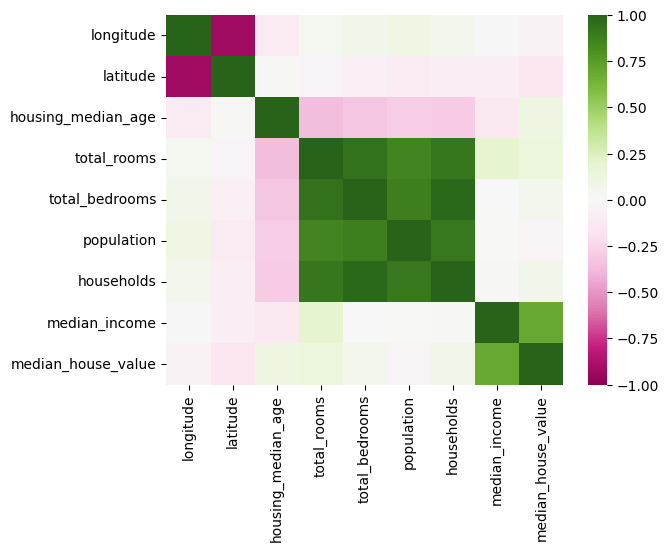

In [16]:
# plot an sns heatmap for our data

sns.heatmap(housing_data.corr(numeric_only=True), cmap='PiYG', vmin=-1, vmax=1);

There are certainly groups of highly correlated features!

Now let's look specifically at how much each individual attribute correlates with our target `median_house_value`, the value we want to predict. Remember, we will call this `y`

In [17]:
# compute the correlation matrix for our data and extract the column for the target.
# sort it in descendig order. You may sort a pandas series using  the method sort_values and setting the ascending kwa to False

housing_data.corr(numeric_only=True)['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

We also have latitude and longitude, so let's visualize the geographical data.

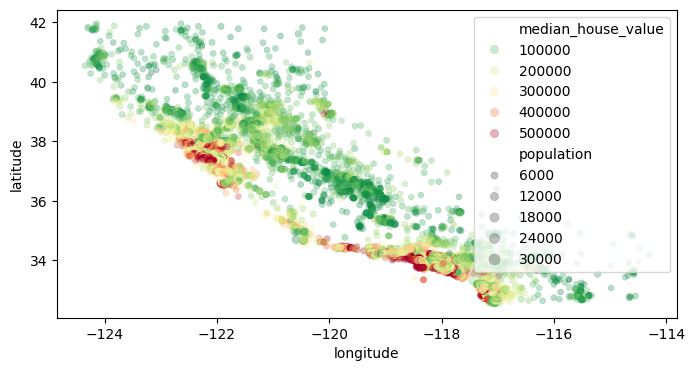

In [18]:
# plot an sns scatterplot with the longitude on the x axis and the latitude on the y axis
# use the size kwa to visualize population and the hue kwa to visualize the target median_house_value
# use a palette of your liking for the color
# you may use the alpha kwa to changed the opacity of the plot to highlight areas with higher density

plt.figure(figsize=(8,4))
sns.scatterplot(x='longitude',y='latitude',
                data=housing_data, size='population',
                hue='median_house_value',
                palette='RdYlGn_r', edgecolor=None, alpha=0.3);

It's pretty neat! Which state is this data from? Can you see it in the plot? Where, geographically, do you find the most expensive houses and dense population? 

Athough the correlation matrix, which looks only at pairs of features, did not pick this up, from these visualizations we can tell that housing prices are very related to location (e.g. close to the ocean) and somewhat to population density.

So far we observed our data to make sense of it. Now we want to prepare it for supervised learning.

<a name="partition"></a>
# Partition into Training and Test set
---
Before we start modifying our data, let's partition the target from the features and set aside the test set for our final model evaluation.     

**IMPORTANT NOTATION:** We will use matrix notation consistently in our code throughout the course as follows:  

$ \bf{X}=
	\begin{bmatrix}
	x_1^{(1)} & x_2^{(1)} & x_3^{(1)} & ... & x_n^{(1)} \\
	x_1^{(2)} & x_2^{(2)} & x_3^{(2)} & ... & x_n^{(2)}\\
	x_1^{(3)} & x_2^{(3)} & x_3^{(3)} & ... & x_n^{(3)}\\
    ... \\
    x_1^{(m)} & x_2^{(m)} & x_3^{(m)} & ... & x_n^{(m)}\\
	\end{bmatrix}
	\quad
	$ $\bf{y}=\begin{bmatrix}
	y^{(1)}  \\
	y^{(2)} \\
	y^{(3)} \\
    ... \\
    y^{(m)}\\
	\end{bmatrix}
	\quad$



* $n$ : the number of features
* $m$ : the number of instances
*  $\bf{X}$ : the training examples, an $m \times n$ matrix
* $\bf{x}_i$: the $i^{th}$ feature, a size $m$ vector
* $\bf{x}^{(i)}$: the $i^{th}$ instance, a size $n$ vector
* $x_j^{(i)}$: the $j^{th}$ feature of the $i^{th}$ instance
* $\bf{y}$ : the labels (for classification) or target value (for regression), a size $m$ vector  
* ${y}^{(i)}$: the label of the $i^{th}$ instance
* $\bf{\hat{y}}$ : the model predictions, a size $m$ vector
* ${\hat{y}}^{(i)}$: the model's prediction for the $i^{th}$ instance



In [19]:
# let's import train_test_split from sklearn
from sklearn.model_selection import train_test_split


In [20]:

# separate the labels (our y, what we want to predict), from the rest of the data.
# drop creates a copy of the original data, axis=1 indicates we are dropping the column
X = housing_data.drop('median_house_value', axis=1)
y = housing_data['median_house_value'] # this is a series, not a dataframe

# set aside 20% of the data for testing, set a random seed so every run will generate the same test set
# note that train_test_split shuffles the data by default (shuffle=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Always make sure you know what type of datastructure you are working with.

In [21]:
type(X_train)

pandas.DataFrame

In [22]:
type(X_test)

pandas.DataFrame

In [23]:
type(y_test)

pandas.Series

It is also important to be aware of the shape of the data, keeping in mind that we are reserving 20% of the instances (20640 * 0.2 = 4128) for the training set.

In [24]:
X.shape

(20640, 9)

In [25]:
X_train.shape

(16512, 9)

In [26]:
X_test.shape

(4128, 9)

<a name="preprocessing"></a>
# Data Preprocessing
---
---




### Missing features
We need to replace missing feature values for a machine learning algorithm to work well. If the fact that a value is missing is significant (e.g., the result of a medical test) it should be coded for with a value (e.g., -1). Since we are doing regression here, the value should be numeric. We could also replace it with the mean or median value calculated from the training set ONLY.

In [27]:
#cannot compute median of categorical data, so extract only numeric data to be replaced with median
X_train_num = X_train.drop('ocean_proximity', axis=1)
X_train_num

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
14196,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596
8267,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125
17445,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563
14265,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425
2271,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542
...,...,...,...,...,...,...,...,...
11284,-117.96,33.78,35.0,1330.0,201.0,658.0,217.0,6.3700
11964,-117.43,34.02,33.0,3084.0,570.0,1753.0,449.0,3.0500
5390,-118.38,34.03,36.0,2101.0,569.0,1756.0,527.0,2.9344
860,-121.96,37.58,15.0,3575.0,597.0,1777.0,559.0,5.7192


Let's do the same with the test set

In [28]:
X_test_num = X_test.drop('ocean_proximity', axis=1)

More sanity testing: we originally had 9  features and just removed 1 categorical feature:

In [29]:
X_train_num.shape

(16512, 8)

In [30]:
X_test_num.shape

(4128, 8)

In [31]:
# sklearn SimpleImputer replaces missing values with a value computed from the column based on the defined strategy
from sklearn.impute import SimpleImputer
imputer = SimpleImputer( strategy = 'median') # replaces missing values with median (other strategies are mean, most frequent and constant)

#now fit (compute the median) - it is important that YOU NEVER FIT ON THE TEST SET!
imputer.fit(X_train_num);


In [32]:
# now we need to actually replace all missing values - imputer can be applied to all columns
X_train_num = imputer.transform(X_train_num)
type(X_train_num)

numpy.ndarray

`imputer.transform()` returns a numpy array, so keep in mind that now X_train_num is a numpy array no longer a pandas dataframe.
To verify that it worked, let's now count the number of null values on the numpy array.

In [33]:
np.count_nonzero(np.isnan(X_train_num))

np.int64(0)

Good, there are 0 True entries in the result of `isnan` (a numpy array with boolean values replacing null and non-null values)  

Now we can remove missing values from the test set. Note, the median was computed on the training set, so we never "look at" the test set. We only `transform` but never `fit` the test set.

In [34]:
X_test_num = imputer.transform(X_test_num)
type(X_test_num)

numpy.ndarray

In [35]:
# check that it worked
np.count_nonzero(np.isnan(X_test_num))

np.int64(0)

### Feature Scaling

This is one of the most important pre-processing steps. Most ML algorithms do not perform well when numeric features are on different scales.

For example, many classifiers calculate the distance between two points by the Euclidean distance. If one of the features has a broad range of values, the Eucledian distance will be heavily influenced by this particular feature. Therefore, the range of all features should be normalized so that each feature contributes approximately proportionately to the final distance.
Another reason why feature scaling is applied is that gradient descent converges much faster with feature scaling than without it. (If you do not understand that last sentence, don't worry, we will talk about gradient descent next week)

Scaling the labels or target values is not necessary.

[*wikipedia.org*](https://en.wikipedia.org/wiki/Feature_scaling)

Here we will look at two types of feature scaling:
* Normalization
* Standardization

#### Normalization
One approach, also known as min-max scaling or min-max normalization, is the simplest method and consists of shifting and rescaling the values of features within the range in [0, 1] or [−1, 1]. These are commonly used in deep learning where we want feature values within these ranges. (More on this later.)   
For range [0, 1] the value of each feature is computed by subtracting the lowest value, then dividing by the difference between the maximum and minimum values.


> ${\bf x'_{i}} = \frac{{\bf x_{i}} - x_{min}}{x_{max} - x_{min}}$


For an arbitrary range [a, b]:



> ${\bf x'_{i}} = \frac{({\bf x_{i}} -  x_{min})(b-a)}{x_{max} - x_{min}}$



Let's use rescaling in our example. Note that `sklearn.processing.MinMaxScaler` defaults to range [0,1]

In [36]:

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_min_max= scaler.fit_transform(X_train_num)
X_train_min_max

array([[0.72908367, 0.01702128, 0.62745098, ..., 0.06437961, 0.10228581,
        0.19032151],
       [0.61653386, 0.12978723, 0.94117647, ..., 0.0367443 , 0.12415721,
        0.22845202],
       [0.38545817, 0.22446809, 0.05882353, ..., 0.02556125, 0.05508962,
        0.25216204],
       ...,
       [0.59462151, 0.15744681, 0.68627451, ..., 0.04913254, 0.08649893,
        0.16789424],
       [0.23804781, 0.53510638, 0.2745098 , ..., 0.04972112, 0.09176122,
        0.35994676],
       [0.19223108, 0.55531915, 1.        , ..., 0.07332044, 0.20407828,
        0.14314285]], shape=(16512, 8))

We also need to scale the test set. Remember, **never fit the test set**, only transform!!!

In [37]:
X_test_min_max = scaler.transform(X_test_num)
X_test_min_max

array([[0.53187251, 0.37340426, 0.47058824, ..., 0.03893046, 0.0588719 ,
        0.08146784],
       [0.48705179, 0.27553191, 0.56862745, ..., 0.04377925, 0.09587239,
        0.14009462],
       [0.19023904, 0.55851064, 1.        , ..., 0.03663219, 0.15819766,
        0.2055282 ],
       ...,
       [0.22908367, 0.50638298, 0.47058824, ..., 0.04433981, 0.09324124,
        0.60205376],
       [0.45717131, 0.44893617, 0.68627451, ..., 0.03430589, 0.07778326,
        0.15759093],
       [0.59561753, 0.17765957, 0.31372549, ..., 0.04675019, 0.07350765,
        0.21049365]], shape=(4128, 8))

#### Standardization (Z-score Normalization)

<img src="images/z-score.png" alt="z-score"> 


Another approach is standardization, which makes the values of each feature in the data have mean 0 and variance 1.   
To do this, one feature at a time, we first calculate the mean $\mu$ (mu) and standard deviation $\sigma$ (sigma). Then for each feature value in each instance, we subtract that feature's mean and divide by that feature's standard deviation.

> ${\bf x'_{i}} = \frac{{\bf x_{i}} - \mu}{\sigma}$


Because all feature values are rescaled in the same way, the overall distribution does not change. Note that Z-score normalization does not bound values to a specific range.

In [38]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler( )
X_train_Z = std_scaler.fit_transform(X_train_num)
X_train_Z

array([[ 1.27258656, -1.3728112 ,  0.34849025, ...,  0.76827628,
         0.32290591, -0.326196  ],
       [ 0.70916212, -0.87669601,  1.61811813, ..., -0.09890135,
         0.6720272 , -0.03584338],
       [-0.44760309, -0.46014647, -1.95271028, ..., -0.44981806,
        -0.43046109,  0.14470145],
       ...,
       [ 0.59946887, -0.75500738,  0.58654547, ...,  0.28983345,
         0.07090859, -0.49697313],
       [-1.18553953,  0.90651045, -1.07984112, ...,  0.30830275,
         0.15490769,  0.96545045],
       [-1.41489815,  0.99543676,  1.85617335, ...,  1.04883375,
         1.94776365, -0.68544764]], shape=(16512, 8))

In [39]:
X_test_Z = std_scaler.transform(X_test_num) #no fitting, only transform
X_test_Z

array([[ 0.28534728,  0.1951    , -0.28632369, ..., -0.03030109,
        -0.37008673, -1.15508475],
       [ 0.06097472, -0.23549054,  0.11043502, ...,  0.12185077,
         0.220532  , -0.70865905],
       [-1.42487026,  1.00947776,  1.85617335, ..., -0.10241931,
         1.21539643, -0.21040155],
       ...,
       [-1.23041404,  0.78014149, -0.28632369, ...,  0.13944058,
         0.17853244,  2.80902421],
       [-0.08860699,  0.52740357,  0.58654547, ..., -0.17541702,
        -0.06821494, -0.57542978],
       [ 0.60445493, -0.66608108, -0.92113763, ...,  0.21507676,
        -0.13646421, -0.17259111]], shape=(4128, 8))

**Which scaling method should you choose?**

- **Normalization (Min-Max)** is a good default when you know the data has a bounded range and you need values strictly within [0, 1] — common in neural networks with sigmoid or ReLU activations, or when the algorithm is sensitive to absolute magnitude (e.g., pixel values in image data).
- **Standardization (Z-score)** is preferred when the data may contain outliers, when you don't know whether the distribution is bounded, or when the algorithm assumes features are roughly normally distributed (e.g., linear models, SVMs, PCA). Z-score scaling does **not** bound values to a fixed range, so outliers are preserved but their influence is dampened relative to the rest of the data.

**In this lab we will continue with Standardization.** Our features (e.g. `total_rooms`, `population`) have significant outliers visible in the histograms above, and we will be training a linear regression, which is sensitive to outliers dominating the scale.

**Note:** Scaling the labels or target values is not necessary because the model learns to predict in whatever units the target is expressed in. Scaling it would change nothing about the model's predictive power. 

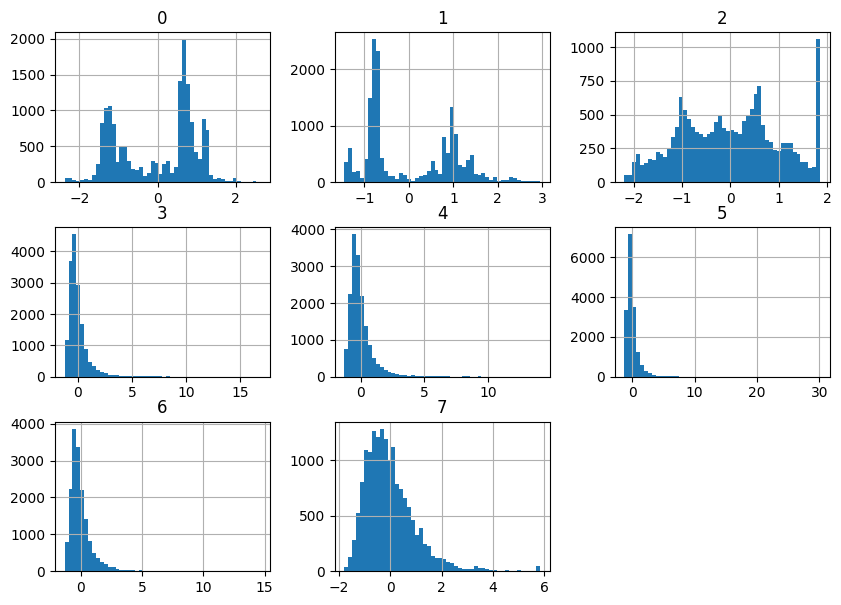

In [40]:
# our standardized data is now a numpy array. convert it to a dataframe
# then use dataframe.hist() to plot the scaled training data
# for better visualization set the bins kwa to 50 and play with the figsize kwa

X_train_plot = pd.DataFrame(X_train_Z)
X_train_plot.hist(bins=50, figsize=(10,7))
plt.show()

And for comparison plot the unscaled training set

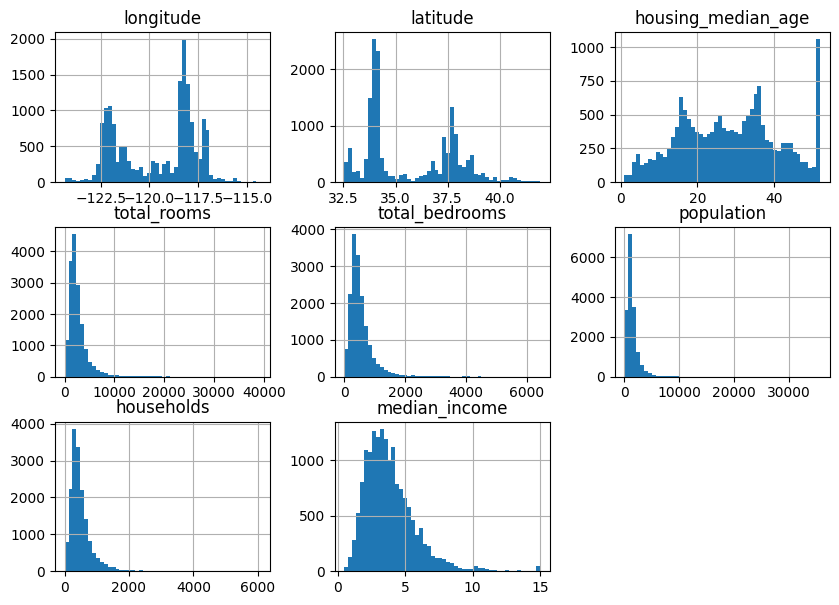

In [41]:
# make the same plot but with the unscaled training data
X_train.hist(bins=50, figsize=(10,7))
plt.show()

The shapes are exactly the same, what's changed?

### Handlng Categorical Attributes
Machine learning models require data to be numeric, so we must encode our categorical data into numbers in order to train a model on this data.    

One approach is **Ordinal Encoding**, assign an integer value to each unique category value, for example, if our categories are "red", "green" and "blue", we can encode these as 1, 2 and 3 repsectively. This can pose a problem for some machile learning algorithms because this encoding implies a ranking (1 < 2 < 3), which is not true of the color categories, so we are encoding infomration that is not accurate.

Another strategy that does not have the implied ranking problem is called **One-Hot Encoding**. This introduces a binary variable for each unique category value. You can think of these as bit representations , where exactly one bit must be on (1) to indicate the value of the category. For example, we can encode our color categoery with red = 100, green = 010 and blue = 001.   

Let's use One-Hot Encoding for our categorical feature:

In [42]:
from sklearn.preprocessing import OneHotEncoder


In [43]:

#extract the categorical column
X_train_cat = X_train[["ocean_proximity"]]


In [44]:
cat_encoder = OneHotEncoder(sparse_output=False)
# sparse_output=False will store the sparse matrix, used here for illustrative purposes
# the dafault sparse_output=True will return a dense array (the sparse matrix in compressed format)
# unintuitive language, but it means it will return a scipy.sparse.csr_matrix object, which is copressed, thus sparse=True

# one-hot encode the categorical data
X_train_1hot = cat_encoder.fit_transform(X_train_cat)
X_train_1hot

array([[0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.]], shape=(16512, 5))

Note that, instead of a single categorical feature, we now have 5 binary features, one for each category. Moreover, despite the fact that each feature is binary (the values will always be either 1 or 0), `HoneHotEncoder` will generate these values as floats that will feed nicely in our ML models.

In [45]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [46]:
type(X_train_1hot[0][0])

numpy.float64

And we also do the same to one-hot encode the test data. Note that we NEVER FIT on the test data.

In [47]:
X_test_cat = X_test[["ocean_proximity"]]
X_test_1hot = cat_encoder.transform(X_test_cat)
X_test_1hot

array([[0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.]], shape=(4128, 5))

Now put the numeric and categorical data back together. We use a new variable `X_train_processed` to make clear this is the fully preprocessed training matrix — distinct from the original `X_train` DataFrame.

In [48]:
X_train_processed = np.concatenate((X_train_Z, X_train_1hot), axis=1)
X_train_processed[0]

array([ 1.27258656, -1.3728112 ,  0.34849025,  0.22256942,  0.21122752,
        0.76827628,  0.32290591, -0.326196  ,  0.        ,  0.        ,
        0.        ,  0.        ,  1.        ])

In [49]:
X_test_processed = np.concatenate((X_test_Z, X_test_1hot), axis=1)
X_test_processed[0]

array([ 0.28534728,  0.1951    , -0.28632369, -0.52286157, -0.24223915,
       -0.03030109, -0.37008673, -1.15508475,  0.        ,  1.        ,
        0.        ,  0.        ,  0.        ])

In [50]:
X_test_processed.shape

(4128, 13)

In [51]:
X_train_processed.shape

(16512, 13)

<a name="model"></a>
# Select and Train the Model
---
Our data is ready: no missing values, all features are numeric and standardized.  
Let's train the simplest model — a linear regression:

$\hat{y} = w_0 + w_1x_1 + ... + w_nx_n$

where the model is a weighted sum of the features. We are fitting a hyperplane in 13D space (8 numeric + 5 one-hot encoded features).

<img src="images/linear_regression.png" alt="linear regression"> 

In [52]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

#we have a linear regression object lin_reg that needs to be trained (fit)
# on our training data X_train_processed using the training labels y_train
lin_reg.fit(X_train_processed, y_train) # uses closed form solution

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


<a name="evaluate"></a>
# Evaluate the model
---
Now we have a linear regression model called `lin_reg` that has been trained (fit) on our prepared training data.  
So how well does it fit our data?  
One way to evaluate our model (how good is it?) is to measure the Root Mean Squared Error (RMSE) on the test set:  


> $RMSE = \sqrt{\frac{1}{m}\sum_{i=1}^{m} (y_i - \hat{y_i})^2}$

The distance, on average, of the predicted values from the actual values.

<img src="images/linear_error.png" alt="linear error" width="700"> .


### Train vs. Test Error

Comparing the error on the training set to the error on the test set is how we diagnose model fit:

| Scenario | Train error | Test error | Interpretation |
|---|---|---|---|
| **Underfitting** | High | High | Model too simple — not capturing the pattern in the data |
| **Overfitting** | Low | High | Model memorised the training data but doesn't generalise |
| **Good fit** | Low | ≈ Low | Model generalises well |

A small gap between train and test error is expected and healthy (the model has seen the training data). A large gap is a red flag for overfitting.

### Baseline: always predict the mean

Before judging whether the computed RMSE is good or bad, we need a reference point. The simplest possible predictor — a **baseline** — is to ignore all features and always predict the mean house value of the training set. Any model worth using must beat this baseline; if it doesn't, the model isn't learning anything useful.

The baseline RMSE is equivalent to the standard deviation of the target values.

In [53]:
from sklearn.metrics import mean_squared_error

In [54]:
# baseline: predict the training mean for every instance
y_baseline = np.full(len(y_test), y_train.mean())
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_baseline))
baseline_rmse

np.float64(114485.63543099792)

In [55]:
# evaluate on the training set
y_hat_train = lin_reg.predict(X_train_processed)
train_rmse = np.sqrt(mean_squared_error(y_train, y_hat_train))
train_rmse

np.float64(68433.93736666226)

In [56]:
#compute the predictions y_hat using the predict() method on the test set
y_hat = lin_reg.predict(X_test_processed)

# evaluate by measuring the mean sqared error between the true target y_test and the predictions y_hat
lin_mse = mean_squared_error(y_test, y_hat)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(70059.19333925015)

### Predicted vs. Actual

A useful way to visualize model quality is to plot the predicted values $\hat{y}$ against the actual values $y$. A perfect model would place every point on the diagonal. The spread around the diagonal gives an intuitive sense of the error.

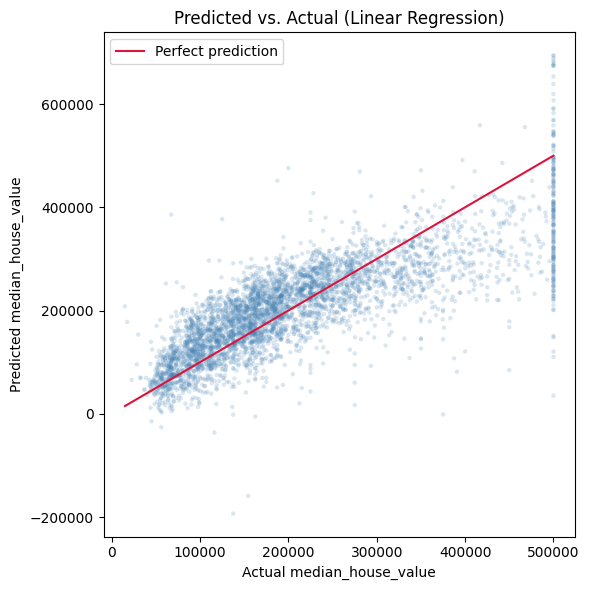

In [57]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_hat, alpha=0.2, edgecolors='none', color='steelblue', s=10)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
        color='crimson', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual median_house_value')
ax.set_ylabel('Predicted median_house_value')
ax.set_title('Predicted vs. Actual (Linear Regression)')
ax.legend()
plt.tight_layout()
plt.show()

Notice the vertical streak of points at the far right of the plot. These are the instances where `median_house_value` is more than \$500,000, the cap we observed earlier in the scatter plot of `median_income` vs `median_house_value`. Because all of these instances share the same actual value (\$500k), they line up on the same x-coordinate, but the model predicts a wide range of values for them since it only sees the features, not the cap. These capped values are effectively noise from the model's perspective and will inflate the RMSE. If model accuracy is the goal, one option is to remove these instances from the dataset before training.

Both train (~\$68k) and test (~\$70k) errors are close to each other, which rules out overfitting — the model is not memorising the training data. However, both are still high in absolute terms.

Comparing against the baseline puts this in perspective:

| Model | RMSE |
|---|---|
| Baseline (predict mean) | ~\$115k |
| Linear Regression (train) | ~\$68k |
| Linear Regression (test) | ~\$70k |

The linear regression beats the baseline by a significant margin, which confirms it **is** learning something from the features. But a ~\$70k error on houses priced between \$120k and \$265k (IQR) is still not useful in practice. This is a symptom of **underfitting**: the model is too simple to capture the non-linear relationships in the data (recall the curved scatter plot of `median_income` vs `median_house_value`). In future labs we will use neural networks to capture these non-linearities.

# Try it yourself: Decision Tree Regressor                                      
                                                                                
A Decision Tree makes predictions by learning a series of if/then rules from the data. Unlike linear regression, it can capture non-linear relationships. 
However it tends to overfit: it can memorize the training data almost perfectly while performing worse on the test set.                                       
                  
Try swapping in a Decision Tree and compare the train and test RMSE to what you got with linear regression. What do you notice?

In [58]:
from sklearn.tree import DecisionTreeRegressor
tree_reg = DecisionTreeRegressor(random_state=42)

In [59]:
# next you fit and evaluate using fit() and predict() similarly to how you did for linear regression

# [Your code here]

# Conclusion

The point here was to describe the supervised learning process and highlight some important concepts in data exploration, partitioning and preprocessing, regardless of the model being trained.  

Next we will learn about Neural Networks and will try it on this dataset to see if we can do any better and why.  
 ___
 ___

 # A Note on Model Evaluation                                                    
                                                                                
  In a typical machine learning workflow, evaluating on the test set only once raises a concern: what if this particular 80/20 split happened to be lucky or 
  unlucky? The standard remedy is k-fold cross-validation, which gives a more reliable estimate of generalization error by averaging results across multiple
   splits of the training data.

We are intentionally skipping that here, as in the coming labs we will transition to neural networks and adopt a training and evaluation approach
better suited to them. We will cover that in detail when we get there.